## RESPONSI MODUL 1

NAMA: MUHAMMAD RIZKY HISYAM

NIM: F1D02410018

KELOMPOK: 15

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

### Persiapan Inisialisasi Library

Tahap ini digunakan untuk memanggil pustaka pendukung yang akan sangat dibutuhkan selama proses komputasi dan visualisasi pengolahan citra.

- `import numpy as np` berfungsi untuk memanggil pustaka komputasi numerik. Library ini digunakan untuk manipulasi matriks dan array, karena citra digital pada dasarnya direpresentasikan sebagai matriks dua dimensi.
- `import matplotlib.pyplot as plt` berfungsi untuk memanggil pustaka visualisasi. Library ini digunakan sebagai kanvas untuk menampilkan gambar pada output program dan mencetak grafik distribusi piksel (histogram).
- `import cv2 as cv` berfungsi untuk memanggil pustaka OpenCV. Sesuai dengan batasan modul, library ini digunakan murni hanya untuk membaca file citra dari direktori lokal dan mengubah ruang warna menjadi grayscale maupun RGB.

### Membaca dan Menampilkan Citra Asli (RGB)

Tahap awal ini digunakan untuk memuat keempat potongan tubuh Buggy yang terpisah dari direktori lokal dan menampilkannya dalam warna aslinya sebelum dikenai efek manipulasi lebih lanjut.

- `cv.imread(...)` berfungsi untuk membaca keempat file gambar potongan Buggy secara individu dari folder `assets` dan menyimpannya ke dalam variabel `buggy1` hingga `buggy4`.
- `cv.cvtColor(..., cv.COLOR_BGR2RGB)` sangat krusial digunakan di sini. OpenCV secara bawaan membaca gambar berwarna dalam format BGR (Blue-Green-Red). Agar warna asli dapat dirender dan ditampilkan dengan benar oleh Matplotlib, format tersebut harus dikonversi menjadi RGB (Red-Green-Blue) standar.
- `plt.figure(figsize=(7, 7))` digunakan untuk mengatur dimensi kanvas visualisasi agar berbentuk bujur sangkar sehingga proporsional untuk menampung keempat gambar.
- `plt.subplot(2, 2, x)` digunakan untuk membagi layout kanvas menjadi bentuk grid 2 baris dan 2 kolom. Parameter `x` (1 sampai 4) menentukan urutan penempatan gambar.
- `plt.axis('off')` digunakan untuk menyembunyikan garis sumbu koordinat agar fokus visual tetap pada objek potongan citra.

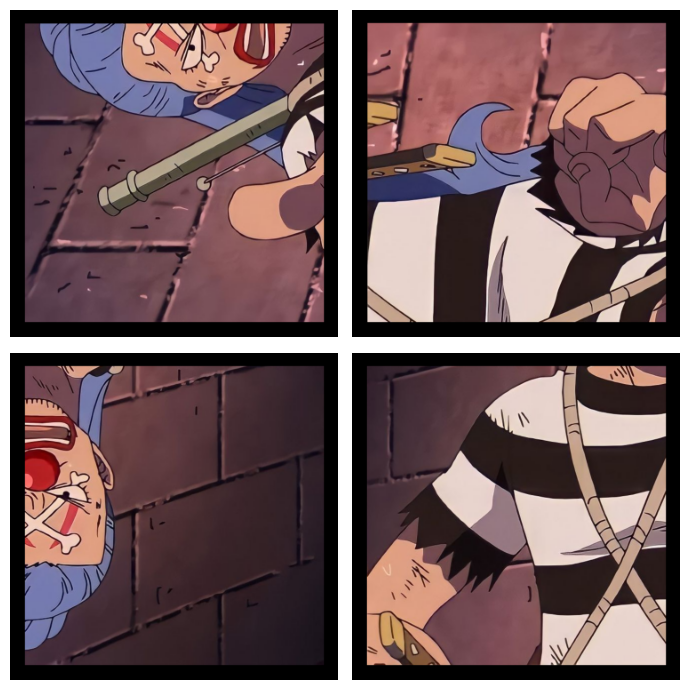

In [3]:
buggy1 = cv.imread("assets/buggy1.png")
buggy2 = cv.imread("assets/buggy2.png")
buggy3 = cv.imread("assets/buggy3.png")
buggy4 = cv.imread("assets/buggy4.png")

rgb1 = cv.cvtColor(buggy1, cv.COLOR_BGR2RGB)
rgb2 = cv.cvtColor(buggy2, cv.COLOR_BGR2RGB)
rgb3 = cv.cvtColor(buggy3, cv.COLOR_BGR2RGB)
rgb4 = cv.cvtColor(buggy4, cv.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.imshow(rgb1)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(rgb2)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rgb3)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(rgb4)
plt.axis('off')

plt.tight_layout()
plt.show()

### Konversi Grayscale dan Visualisasi Subplot

Tahap ini bertujuan untuk menyeragamkan format warna keempat potongan citra sesuai dengan skenario bahwa warna asli Buggy telah memudar menjadi intensitas abu-abu, lalu menampilkannya secara berdampingan untuk dianalisis orientasinya.

- `cv.cvtColor(..., cv.COLOR_BGR2GRAY)` berfungsi untuk mengubah ruang warna matriks citra dari format bawaan BGR menjadi *grayscale* (keabuan). Hal ini penting dilakukan agar matriks citra hanya memiliki satu saluran warna tunggal, sehingga mempermudah operasi matematis pada tahap selanjutnya.
- `plt.figure(figsize=(7, 7))` digunakan untuk mengatur dimensi kanvas visualisasi agar berbentuk bujur sangkar dengan rasio 7x7 inci, sehingga proporsional untuk menampung empat gambar.
- `plt.subplot(2, 2, x)` digunakan untuk membagi kanvas menjadi bentuk grid 2 baris dan 2 kolom. Parameter `x` (1 sampai 4) menentukan urutan penempatan gambar dari kiri atas hingga kanan bawah.
- `plt.imshow(..., cmap='gray')` berfungsi untuk menampilkan citra. Parameter `cmap='gray'` wajib ditambahkan agar Matplotlib melakukan pemetaan warna abu-abu yang akurat di layar, alih-alih menggunakan spektrum warna bawaannya.
- `plt.axis('off')` digunakan untuk menghilangkan garis koordinat agar tampilan gambar tidak terganggu oleh angka sumbu.

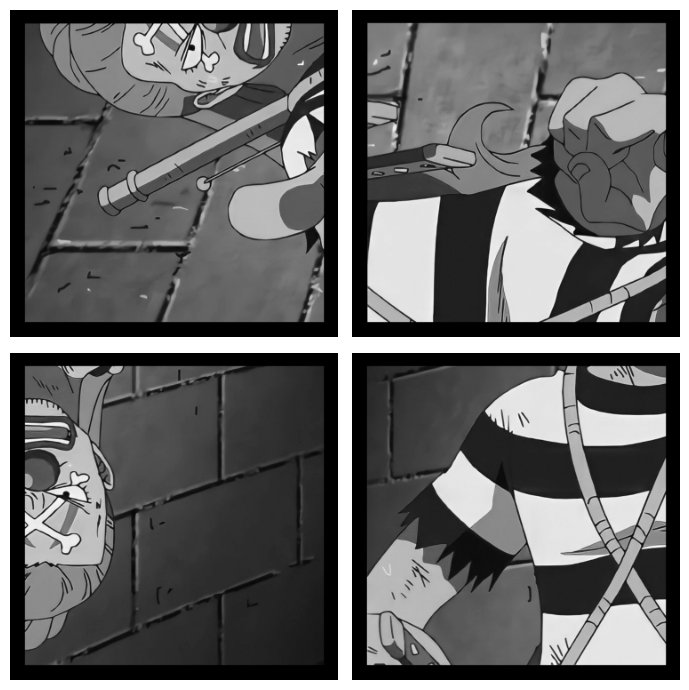

In [4]:
gray1 = cv.cvtColor(buggy1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(buggy2, cv.COLOR_BGR2GRAY)
gray3 = cv.cvtColor(buggy3, cv.COLOR_BGR2GRAY)
gray4 = cv.cvtColor(buggy4, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray2, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gray3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gray4, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
def fungsi_rot(image, val): 
    h, w = image.shape 
    val = int(val) % 360  
    if val == 0: 
        return image
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[w - 1 - j, i] = image[i, j] 
        return rot 
    return image

def fungsi_flip(image, mode='x'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'x':  
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'y':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

### Definisi Fungsi Rotasi dan Pencerminan (Flip)

Tahap ini mendefinisikan fungsi kustom untuk melakukan operasi pemutaran (rotasi) dan pencerminan matriks citra secara manual berdasarkan transformasi koordinat indeks tanpa menggunakan fungsi bawaan dari library.

**1. Fungsi Rotasi Citra (`fungsi_rot`)**
- `h, w = image.shape` berfungsi untuk mengekstrak nilai tinggi (baris) dan lebar (kolom) dari matriks citra input untuk mengetahui dimensinya.
- `val = int(val) % 360` digunakan untuk menormalisasi nilai sudut masukan. Operasi modulo 360 memastikan bahwa berapapun nilai sudut yang diinputkan, hasilnya akan selalu dipetakan secara melingkar dalam rentang standar 0 hingga 359 derajat.
- Blok kondisi `if-elif` digunakan untuk memisahkan logika perhitungan perpindahan koordinat piksel berdasarkan sudut rotasi kelipatan tegak lurus, yaitu 0, 90, 180, dan 270 derajat.
- `np.zeros((w, h), dtype=image.dtype)` yang ada pada blok rotasi 90 dan 270 derajat berfungsi untuk membuat kanvas matriks hitam (kosong) baru. Dimensinya sengaja dibalik dari `(h, w)` menjadi `(w, h)` karena perputaran tersebut akan mengubah orientasi rasio gambar.
- `np.zeros_like(image, dtype=image.dtype)` yang ada pada blok rotasi 180 derajat digunakan untuk membuat matriks kosong dengan ukuran yang sama persis seperti citra asal.
- Perulangan bersarang `for i` dan `for j` berfungsi untuk mengiterasi setiap baris dan kolom piksel, lalu memindahkan nilainya dari koordinat awal `image[i, j]` ke posisi indeks yang baru sesuai rumus transformasi.

**2. Fungsi Pencerminan Citra (`fungsi_flip`)**
- `def fungsi_flip(image, mode='x'):` berfungsi untuk mendeklarasikan fungsi pencerminan dengan parameter `mode` yang secara bawaan diatur sebagai 'x' untuk pencerminan horizontal.
- `hasil = np.zeros((h, w), dtype=image.dtype)` berfungsi untuk menginisialisasi matriks kosong dengan dimensi dan tipe data yang sama persis dengan citra asli sebagai wadah hasil.
- `if mode == 'x':` mengeksekusi algoritma pencerminan horizontal (terhadap sumbu x). Nilai piksel baru diambil dari matriks asli pada baris yang sama `[i]`, namun dari posisi kolom yang saling berkebalikan letaknya `[w - 1 - j]`.
- `elif mode == 'y':` mengeksekusi algoritma pencerminan vertikal (terhadap sumbu y). Nilai piksel baru diambil dari matriks asli pada kolom yang sama `[j]`, namun dari posisi baris yang saling berkebalikan `[h - 1 - i]`.

### Eksekusi Perbaikan Orientasi dan Penataan Ulang

Tahap ini digunakan untuk mengaplikasikan fungsi rotasi dan pencerminan yang telah didefinisikan sebelumnya, yang berfungsi sebagai metode untuk memperbaiki orientasi anatomi tubuh Buggy yang teracak akibat efek Bara Bara no Mi, sekaligus menempatkannya pada posisi kuadran yang benar.

Berdasarkan analisis visual terhadap citra masukan:

- `fix_1 = fungsi_rot(gray1, 90)` digunakan untuk mengeksekusi perputaran citra sebesar 90 derajat searah jarum jam. Proses ini berfungsi sebagai perbaikan orientasi pada potongan pertama (sisi kiri wajah dan senjata) agar kembali tegak lurus, dan tetap diposisikan di kuadran kiri atas.
- `fix_2 = fungsi_flip(gray3, mode='y')` digunakan untuk mengeksekusi pencerminan secara vertikal (`mode='y'`). Langkah ini berfungsi sebagai perbaikan pada potongan ketiga (sisi kanan wajah) yang sebelumnya dalam keadaan terbalik, untuk kemudian direlokasi letaknya menjadi kuadran kanan atas.
- `fix_3 = fungsi_rot(gray2, 270)` digunakan untuk mengeksekusi perputaran citra sebesar 270 derajat (atau setara 90 derajat berlawanan arah jarum jam). Operasi ini berfungsi sebagai perbaikan pada potongan kedua (tangan menunjuk) agar arah tangannya sesuai, lalu direlokasi ke kuadran kiri bawah.
- `fix_4 = fungsi_flip(gray4, mode='x')` digunakan untuk mengeksekusi pencerminan secara horizontal (`mode='x'`). Proses ini berfungsi sebagai perbaikan pada potongan keempat (bagian torso) agar arah lengannya selaras dengan sisa tubuh, dan tetap dipertahankan pada posisi kanan bawah.

Seluruh hasil perbaikan orientasi tersebut kemudian divisualisasikan kembali menggunakan blok `plt.subplot`, yang berfungsi sebagai tahap validasi untuk memastikan bahwa susunan anatominya sudah tepat meskipun masih dibatasi oleh *padding* hitam.

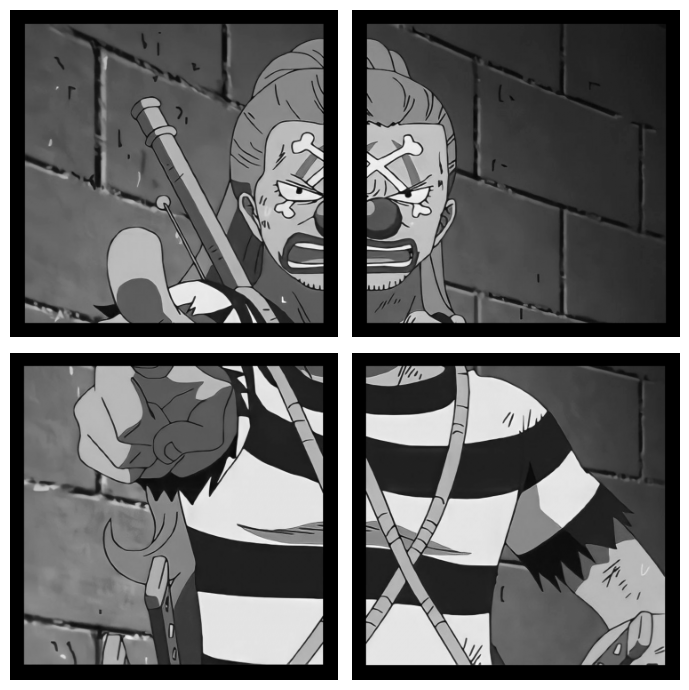

In [6]:
fix_1 = fungsi_rot(gray1, 90)       
fix_2 = fungsi_flip(gray3, mode='y')     
fix_3 = fungsi_rot(gray2, 270) 
fix_4 = fungsi_flip(gray4, mode='x')


plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.imshow(fix_1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(fix_2, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(fix_3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(fix_4, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
def fungsi_crop(image, atas=0, bawah=0, kiri=0, kanan=0):
    h, w = image.shape
    hasil_crop = image[atas : h - bawah, kiri : w - kanan]
    return hasil_crop

### Definisi Fungsi Pemotongan Citra (Cropping)

Tahap ini digunakan untuk mendefinisikan fungsi kustom dalam memotong matriks citra berdasarkan margin yang ditentukan, serta berfungsi sebagai langkah krusial untuk menghilangkan ruang kosong atau *padding* hitam di sekeliling potongan tubuh Buggy akibat efek transformasi.

- `def fungsi_crop(image, atas=0, bawah=0, kiri=0, kanan=0):` berfungsi sebagai deklarasi fungsi pemotongan dengan parameter opsional untuk batas atas, bawah, kiri, dan kanan. Secara bawaan (default), nilai margin diatur ke 0 agar matriks tidak terpotong jika parameter tidak diisi.
- `h, w = image.shape` digunakan untuk mengekstrak dimensi tinggi (baris) dan lebar (kolom) dari matriks citra masukan, yang berfungsi sebagai acuan batas maksimal matriks sebelum dipotong.
- `hasil_crop = image[atas : h - bawah, kiri : w - kanan]` digunakan untuk mengeksekusi inti dari operasi *cropping* yang memanfaatkan teknik *array slicing* (pengirisan array) pada NumPy.
  - Sumbu baris (Y) digunakan untuk mengambil matriks mulai dari indeks `atas` hingga batas `h - bawah`.
  - Sumbu kolom (X) digunakan untuk mengambil matriks mulai dari indeks `kiri` hingga batas `w - kanan`.
  - Teknik ini berfungsi sebagai metode efektif untuk mengabaikan piksel-piksel di area tepi luar matriks (yang merupakan *padding* hitam) dan hanya mengekstrak objek utama di tengahnya.
- `return hasil_crop` berfungsi untuk mengembalikan matriks citra baru yang ukurannya sudah disesuaikan dan bersih dari tepi hitam.

### Eksekusi Penghapusan Padding Hitam (Cropping Citra)

Tahap ini digunakan untuk mengaplikasikan fungsi pemotongan yang telah dideklarasikan sebelumnya, yang berfungsi sebagai pembuang batas ruang kosong (*padding* hitam) di sekeliling setiap potongan tubuh Buggy akibat operasi matriks sebelumnya.

- `crop_1` hingga `crop_4` berfungsi sebagai variabel baru yang dialokasikan untuk menyimpan hasil pemotongan dari matriks citra yang orientasinya sudah diperbaiki (`fix_1` hingga `fix_4`).
- Pemanggilan fungsi `fungsi_crop(..., atas=18, bawah=18, kiri=18, kanan=18)` digunakan untuk menetapkan parameter margin sebesar 18 piksel untuk keempat sisi. Angka ini didapatkan melalui proses observasi visual dan eksperimen, yang berfungsi sebagai nilai paling presisi untuk menghilangkan area *padding* hitam secara menyeluruh tanpa mengorbankan informasi piksel pada objek tubuh Buggy.
- Blok kode visualisasi Matplotlib digunakan untuk memvalidasi hasil akhir dari proses *cropping*. Visualisasi ini berfungsi sebagai bukti bahwa keempat potongan citra kini tampak jauh lebih bersih, proporsional, dan siap untuk disatukan kembali (di-*merge*) pada tahap selanjutnya.

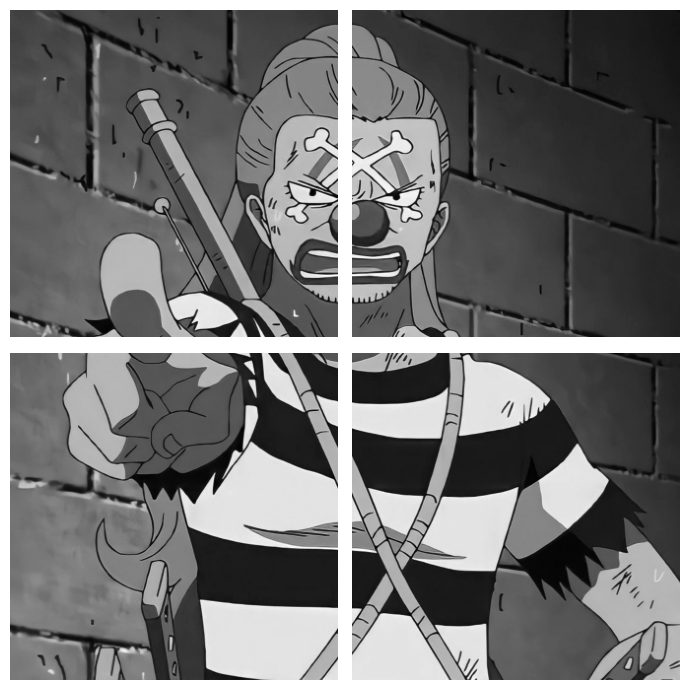

In [8]:
crop_1 = fungsi_crop(fix_1, atas=18, bawah=18, kiri=18, kanan=18)
crop_2 = fungsi_crop(fix_2, atas=18, bawah=18, kiri=18, kanan=18)
crop_3 = fungsi_crop(fix_3, atas=18, bawah=18, kiri=18, kanan=18)
crop_4 = fungsi_crop(fix_4, atas=18, bawah=18, kiri=18, kanan=18)

plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.imshow(crop_1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(crop_2, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(crop_3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(crop_4, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
def fungsi_merge_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def fungsi_merge_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

### Definisi Fungsi Penggabungan Citra (Merge)

Tahap ini digunakan untuk mendefinisikan dua fungsi kustom yang berfungsi sebagai alat untuk menyatukan kembali potongan-potongan matriks citra yang telah diperbaiki orientasi dan ukurannya. Penggabungan ini digunakan untuk merekonstruksi tubuh Buggy secara spasial, baik pada sumbu horizontal maupun vertikal, sehingga menjadi satu kesatuan gambar yang utuh.

**1. Fungsi Penggabungan Horizontal (`fungsi_merge_b`)**
- `fungsi_merge_b` berfungsi sebagai fungsi yang dirancang khusus untuk menyambungkan dua citra secara berdampingan (kiri dan kanan).
- `tinggi = max(c1.shape[0], c2.shape[0])` digunakan untuk menentukan tinggi kanvas baru berdasarkan nilai tinggi maksimum antara citra pertama dan kedua, yang berfungsi sebagai langkah pencegahan agar tidak ada baris yang terpotong.
- `lebar = c1.shape[1] + c2.shape[1]` digunakan untuk menentukan lebar kanvas baru dengan menjumlahkan total lebar kedua citra.
- `hasil = np.zeros(...)` berfungsi sebagai inisialisasi kanvas matriks kosong (bernilai 0/hitam) dengan dimensi baru tersebut.
- Teknik *array slicing* digunakan untuk menyisipkan citra pertama (`c1`) mulai dari kolom ke-0 (kiri), sedangkan citra kedua (`c2`) digunakan untuk mengisi area mulai dari batas akhir kolom citra pertama (`c1.shape[1]:`) hingga selesai di sisi kanan.

**2. Fungsi Penggabungan Vertikal (`fungsi_merge_c`)**
- `fungsi_merge_c` berfungsi sebagai fungsi yang dirancang untuk menumpuk dua citra secara vertikal (atas dan bawah).
- `tinggi = c1.shape[0] + c2.shape[0]` digunakan untuk menentukan tinggi kanvas baru dengan menjumlahkan total tinggi kedua citra.
- `lebar = max(c1.shape[1], c2.shape[1])` digunakan untuk menentukan lebar kanvas baru berdasarkan nilai lebar maksimum antara citra pertama dan kedua.
- `hasil = np.zeros(...)` berfungsi sebagai inisialisasi kanvas matriks kosong dengan dimensi vertikal yang baru.
- Teknik *array slicing* digunakan untuk meletakkan citra pertama (`c1`) di bagian atas matriks (mulai dari baris ke-0), dan citra kedua (`c2`) digunakan untuk mengisi area tepat di bawah batas akhir baris citra pertama (`c1.shape[0]:`).

### Eksekusi Perakitan Citra Utuh (Merge)

Tahap ini digunakan untuk memproses finalisasi rekonstruksi spasial, yang berfungsi sebagai langkah penggabungan keempat potongan citra yang telah diperbaiki orientasinya dan dibersihkan dari *padding* menjadi satu matriks citra yang utuh.

- `gabung_atas = fungsi_merge_b(crop_1, crop_2)` digunakan untuk mengeksekusi penggabungan horizontal yang berfungsi sebagai pembentuk setengah bagian atas tubuh Buggy, dengan cara menyambungkan citra kuadran kiri atas (`crop_1`) berdampingan dengan kuadran kanan atas (`crop_2`).
- `gabung_bawah = fungsi_merge_b(crop_3, crop_4)` digunakan untuk mengeksekusi penggabungan horizontal yang berfungsi sebagai pembentuk setengah bagian bawah tubuh, dengan cara menyambungkan citra kuadran kiri bawah (`crop_3`) berdampingan dengan kuadran kanan bawah (`crop_4`).
- `buggy_utuh = fungsi_merge_c(gabung_atas, gabung_bawah)` digunakan untuk mengeksekusi penggabungan vertikal sebagai langkah terakhir. Proses ini berfungsi sebagai penumpuk blok matriks bagian atas (`gabung_atas`) di atas blok matriks bagian bawah (`gabung_bawah`), sehingga menghasilkan wujud anatomi yang utuh dan sempurna.
- Blok visualisasi menggunakan `plt.imshow` dan `plt.title('Buggy the Clown')` digunakan untuk menampilkan hasil akhir, yang berfungsi sebagai pembuktian bahwa proses restorasi berhasil dilakukan dengan tingkat presisi yang tinggi, ditandai dengan garis patahan yang minim dan wujud karakter yang jelas.

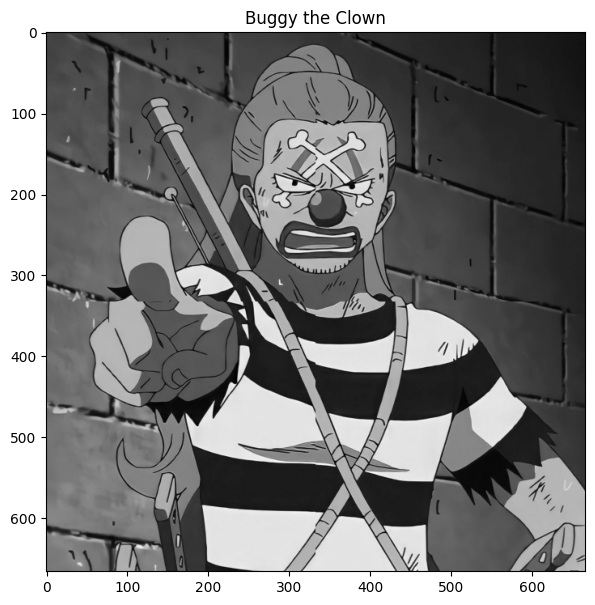

In [10]:
gabung_atas = fungsi_merge_b(crop_1, crop_2)
gabung_bawah = fungsi_merge_b(crop_3, crop_4)
buggy_utuh = fungsi_merge_c(gabung_atas, gabung_bawah)

plt.figure(figsize=(7, 7))
plt.imshow(buggy_utuh, cmap="gray")
plt.title('Buggy the Clown')
plt.show()

In [11]:
def normalisasi_citra(image):
    min_val = np.min(image)
    max_val = np.max(image)
    
    if max_val == min_val:
        return image
        
    norm_img = (image - min_val) / (max_val - min_val) * 255
    return norm_img.astype(np.uint8)

def hitung_histogram(image):
    tinggi, lebar = image.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(tinggi):
        for j in range(lebar):
            val = int(image[i, j])
            hist[val] += 1
            
    return hist

### Definisi Fungsi Normalisasi dan Histogram Manual

Tahap ini digunakan untuk mendeklarasikan fungsi kustom yang bertujuan meregangkan kontras citra (normalisasi) dan menghitung distribusi frekuensi intensitas pikselnya (histogram) tanpa menggunakan fungsi bawaan secara langsung.

**1. Fungsi Normalisasi Citra (`normalisasi_citra`)**
- `def normalisasi_citra(image):` berfungsi sebagai fungsi utama untuk melakukan peregangan kontras (*contrast stretching*) menggunakan algoritma Min-Max.
- `np.min(image)` dan `np.max(image)` digunakan untuk mengekstrak nilai intensitas piksel terendah (paling gelap) dan tertinggi (paling terang) dari matriks citra masukan.
- Blok kondisi `if max_val == min_val:` berfungsi sebagai bentuk penanganan eror (*error handling*) untuk mencegah terjadinya pembagian dengan nol (*ZeroDivisionError*) apabila citra masukannya berupa warna solid (blank).
- `norm_img = (image - min_val) / (max_val - min_val) * 255` digunakan untuk merentangkan secara linear seluruh nilai intensitas piksel agar memenuhi kapasitas maksimal ruang warna 8-bit, yaitu dari 0 hingga 255.
- `.astype(np.uint8)` digunakan untuk mengonversi tipe data hasil perhitungan matriks kembali menjadi *unsigned integer* 8-bit agar format citranya valid dan dapat dirender dengan tepat.

**2. Fungsi Perhitungan Histogram (`hitung_histogram`)**
- `def hitung_histogram(image):` berfungsi sebagai fungsi untuk melakukan pencacahan atau perhitungan frekuensi kemunculan setiap nilai tingkat keabuan pada citra.
- `hist = np.zeros(256, dtype=int)` digunakan untuk menginisialisasi array kosong dengan panjang 256 elemen. Array ini berfungsi sebagai wadah untuk menampung jumlah piksel pada masing-masing tingkat intensitas (0 - 255).
- Perulangan bersarang `for i` dan `for j` digunakan untuk melakukan iterasi atau pemindaian ke seluruh koordinat matriks citra, dari baris pertama hingga terakhir, dan kolom pertama hingga terakhir.
- `hist[val] += 1` berfungsi sebagai penghitung (*counter*) otomatis. Setiap kali program menemukan piksel dengan nilai tertentu, program akan menambah angka 1 pada indeks array `hist` yang sesuai dengan nilai tersebut.

### Eksekusi Normalisasi Citra dan Visualisasi Histogram

Tahap ini digunakan untuk menerapkan fungsi normalisasi pada citra yang telah direkayasa intensitasnya, serta memvisualisasikan perbandingan distribusi pikselnya menggunakan grafik histogram.

- `buggy_redup = buggy_utuh // 2` digunakan untuk merekayasa atau menurunkan nilai intensitas piksel citra utuh menjadi setengahnya (redup). Langkah ini berfungsi sebagai simulasi untuk menghasilkan citra dengan kontras yang rendah agar efek normalisasi dapat divalidasi dengan jelas.
- `buggy_normal = normalisasi_citra(buggy_redup)` digunakan untuk memanggil fungsi peregangan kontras. Operasi ini berfungsi sebagai metode untuk mengembalikan kecerahan dan memperlebar rentang dinamis citra agar kembali optimal.
- Variabel `hist_sebelum` dan `hist_sesudah` berfungsi sebagai wadah untuk menyimpan array hasil pencacahan nilai piksel dari citra redup dan citra normalisasi, yang diekstrak menggunakan fungsi `hitung_histogram`.
- `kanvas_x = [i for i in range(256)]` digunakan untuk membuat *list* berisi angka 0 hingga 255 yang berfungsi sebagai acuan skala sumbu X (nilai intensitas) pada grafik.
- `plt.bar(...)` digunakan untuk menggambar diagram batang histogram. Warna biru diberikan untuk histogram awal yang wujud grafiknya memadat di sisi kiri, sedangkan warna hijau digunakan untuk histogram akhir yang wujud penyebaran intensitasnya sudah lebih merata.
- `plt.xlim(0, 255)` berfungsi sebagai pengunci batas skala sumbu horizontal. Parameter ini digunakan untuk memastikan kanvas selalu menampilkan rentang 8-bit secara penuh (0 - 255), sehingga visualisasi pergeseran kontras dapat diamati secara presisi.

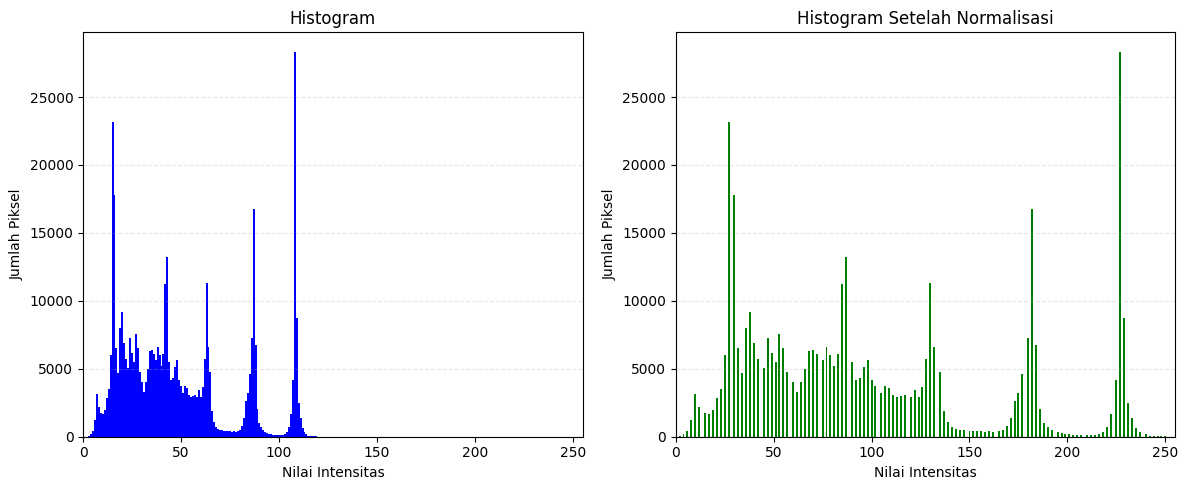

In [12]:
buggy_redup = buggy_utuh // 2

buggy_normal = normalisasi_citra(buggy_redup)

hist_sebelum = hitung_histogram(buggy_redup)
hist_sesudah = hitung_histogram(buggy_normal)

kanvas_x = [i for i in range(256)]

plt.figure(figsize=(12, 5))

# Plot Histogram Sebelum (Biru)
plt.subplot(1, 2, 1)
plt.bar(kanvas_x, hist_sebelum, color='blue', width=1)
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Plot Histogram Sesudah (Hijau)
plt.subplot(1, 2, 2)
plt.bar(kanvas_x, hist_sesudah, color='green', width=1)
plt.title('Histogram Setelah Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Definisi dan Eksekusi Operasi Konvolusi dengan Zero Padding

Tahap terakhir ini digunakan untuk menerapkan operasi *filtering* spasial pada citra menggunakan matriks kernel tertentu untuk memanipulasi frekuensi tinggi (detail dan garis tepi) pada gambar.

**1. Definisi Kernel (High-Pass Filter)**
- Variabel `kernel = np.array(...)` digunakan untuk mendefinisikan matriks filter berukuran 4x4. Matriks ini memiliki nilai pusat yang besar (positif) dan nilai sekeliling yang negatif, yang secara matematis berfungsi sebagai *High-Pass Filter*. Filter ini digunakan untuk menonjolkan perbedaan intensitas yang drastis, sehingga menghasilkan efek penajaman (*sharpening*) dan penegasan garis tepi (*edge detection*).

**2. Fungsi Konvolusi Manual (`fungsi_konvolusi`)**
- `def fungsi_konvolusi(image, kernel):` berfungsi sebagai fungsi kustom untuk mengeksekusi perkalian matriks secara bergeser (*sliding window*).
- `ukuran_padding = kh // 2` digunakan untuk menghitung rasio ketebalan bingkai tambahan berdasarkan tinggi matriks kernel.
- `np.pad(..., mode='constant', constant_values=0)` digunakan untuk menambahkan *Zero Padding* (piksel bernilai 0/hitam) di sekeliling citra asli. Teknik ini berfungsi sebagai metode penjagaan dimensi, agar piksel yang berada di paling tepi citra tetap dapat dikalkulasi oleh kernel tanpa menyebabkan penyusutan ukuran gambar (dimensi input sama dengan dimensi output).
- `hasil = np.zeros(...)` berfungsi sebagai wadah kanvas kosong untuk menampung nilai piksel baru hasil perhitungan.
- Perulangan bersarang `for i` dan `for j` digunakan untuk memindahkan matriks kernel setahap demi setahap ke seluruh koordinat citra.
- `area = padded_img[...]` berfungsi sebagai proses ekstraksi sub-matriks (*slicing*) dari citra yang ukurannya disamakan dengan kernel.
- `val = np.sum(area * kernel)` digunakan untuk menghitung nilai piksel baru melalui operasi jumlah perkalian (*dot product* antara elemen).
- Blok kondisi `if val < 0:` dan `elif val > 255:` berfungsi sebagai proses pembatasan nilai (*clipping*). Pemotongan nilai ini wajib digunakan untuk memastikan hasil perhitungan matematis yang *out of bounds* tidak merusak citra, melainkan dipaksa kembali ke dalam batas rentang warna 8-bit yang valid (0 hingga 255).
- `.astype(np.uint8)` berfungsi sebagai konversi akhir tipe data agar matriks kembalian dapat dibaca sebagai citra digital.

**3. Eksekusi dan Visualisasi Final**
- `buggy_final = fungsi_konvolusi(buggy_normal, kernel)` digunakan untuk mengaplikasikan fungsi yang telah dibuat pada citra Buggy hasil normalisasi.
- Blok `plt.imshow(...)` dan kawan-kawannya berfungsi sebagai penampil hasil akhir dari seluruh rangkaian pengolahan citra. Terlihat pada hasil akhir ("Hasil Konvolusi Buggy Final Boss") bahwa kontras garis pakaian dan raut wajah karakter tampak sangat kasar dan tajam akibat efek filter tersebut.

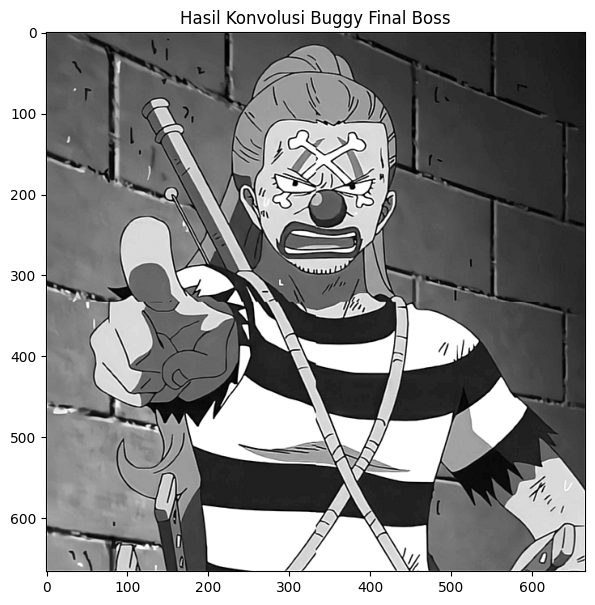

In [13]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def fungsi_konvolusi(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    
    ukuran_padding = kh // 2
    padded_img = np.pad(image, pad_width=ukuran_padding, mode='constant', constant_values=0)
    
    hasil = np.zeros((h, w), dtype=float)
    
    for i in range(h):
        for j in range(w):
            area = padded_img[i : i + kh, j : j + kw]
            val = np.sum(area * kernel)
            
            # Proses Clipping
            if val < 0:
                val = 0
            elif val > 255:
                val = 255
                
            hasil[i, j] = val
            
    return hasil.astype(np.uint8)

buggy_final = fungsi_konvolusi(buggy_normal, kernel)

plt.figure(figsize=(7, 7))
plt.imshow(buggy_final, cmap="gray")
plt.title('Hasil Konvolusi Buggy Final Boss')
plt.show()